In [5]:
import pandas as pd
import numpy as np

# Set seed agar hasil random bisa direproduksi (konsisten)
np.random.seed(42)

# 1. Setup Data Harian (365 Hari)
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')
n = len(dates)
# 2. Generate Harga (Price)
prices = np.random.randint(low=30000, high=70001, size=n)
# 3. Generate Quantity Sold (Hukum Ekonomi)
# Logika: Q = Intercept - (Slope * Price) + Noise
slope = 0.002 
intercept = 250 

# Hitung permintaan dasar
base_qty = intercept - (prices * slope)
noise = np.random.normal(loc=0, scale=15, size=n)

qty_sold = base_qty + noise

# 4. Cleaning & Formatting
qty_sold = np.maximum(qty_sold, 0)

# Bulatkan ke integer (karena penjualan barang harus bilangan bulat)
qty_sold = qty_sold.astype(int)

# 5. Simpan ke DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Price': prices,
    'Qty_Sold': qty_sold
})

df = df.sort_values('Date')

# 6. Tampilkan Hasil
print("Informasi Dataset:")
print(df.info())
print("\n5 Baris Pertama Data:")
print(df.head())

# Cek korelasi sekilas untuk memastikan hukum ekonomi berlaku
corr = df['Price'].corr(df['Qty_Sold'])
print(f"\nKorelasi Harga vs Penjualan: {corr:.2f} (Harusnya mendekati -1)")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      365 non-null    datetime64[ns]
 1   Price     365 non-null    int32         
 2   Qty_Sold  365 non-null    int32         
dtypes: datetime64[ns](1), int32(2)
memory usage: 5.8 KB
None

5 Baris Pertama Data:
        Date  Price  Qty_Sold
0 2024-01-01  45795       165
1 2024-01-02  30860       201
2 2024-01-03  68158        95
3 2024-01-04  41284       162
4 2024-01-05  36265       170

Korelasi Harga vs Penjualan: -0.85 (Harusnya mendekati -1)


Koefisien Korelasi (Pearson): -0.85


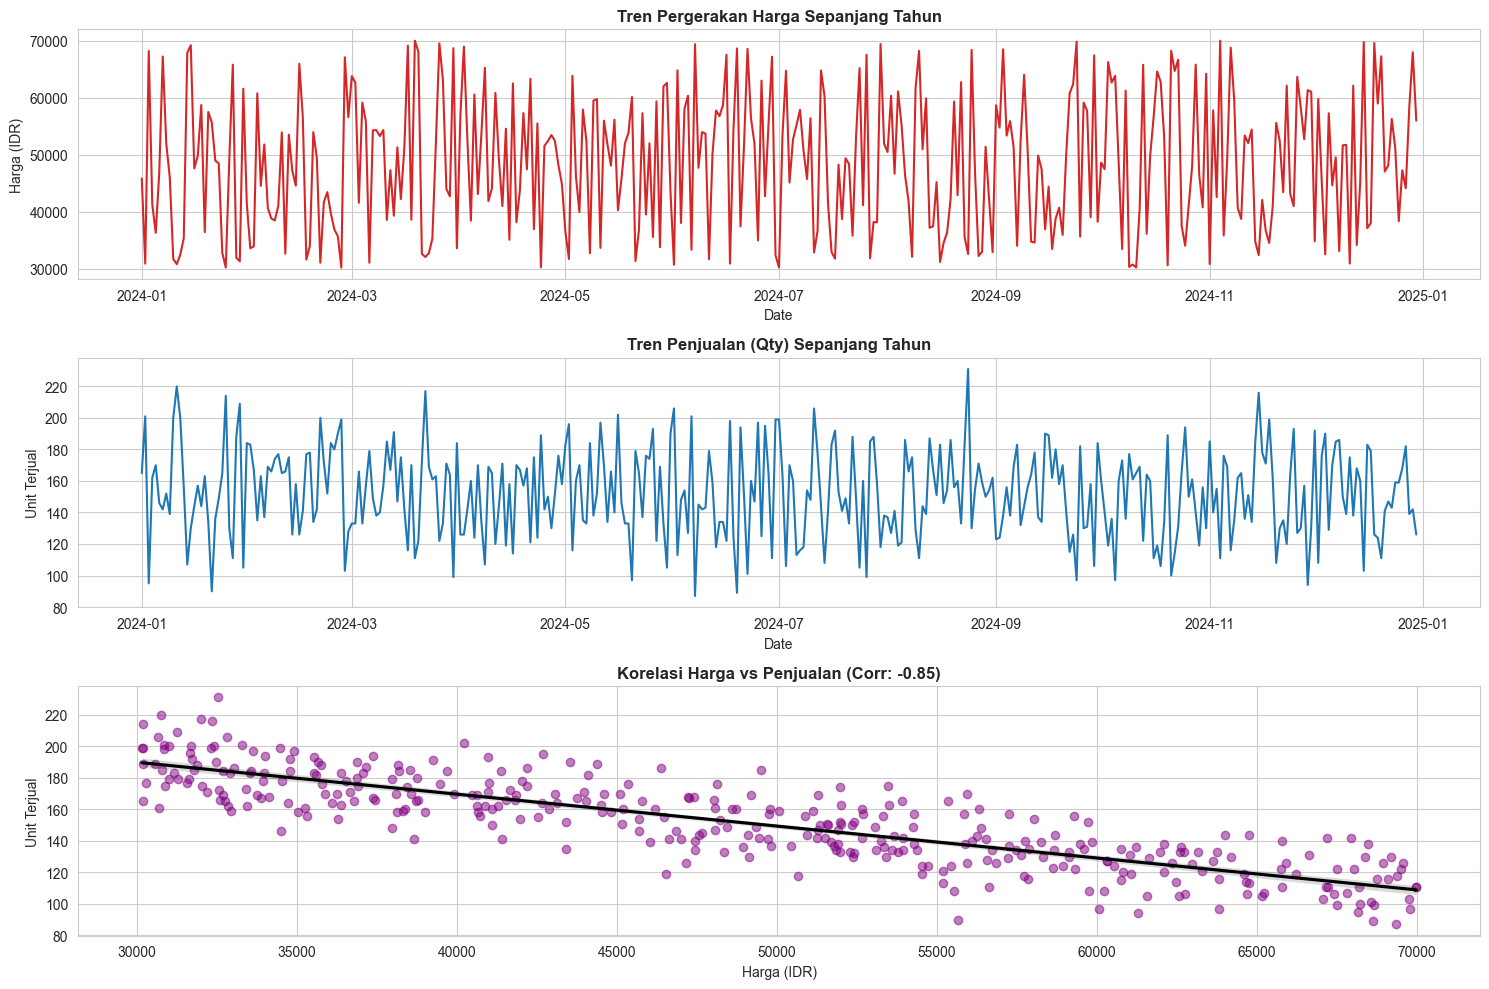

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# A. Hitung Korelasi
correlation = df['Price'].corr(df['Qty_Sold'])
print(f"Koefisien Korelasi (Pearson): {correlation:.2f}")

# B. Visualisasi (3 Plot Sekaligus)
fig, axes = plt.subplots(3, 1, sharex=False)

# Plot 1: Tren Harga per Waktu (Time Series)
sns.lineplot(ax=axes[0], x='Date', y='Price', data=df, color='tab:red')
axes[0].set_title('Tren Pergerakan Harga Sepanjang Tahun', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Harga (IDR)')

# Plot 2: Tren Quantity per Waktu (Time Series)
sns.lineplot(ax=axes[1], x='Date', y='Qty_Sold', data=df, color='tab:blue')
axes[1].set_title('Tren Penjualan (Qty) Sepanjang Tahun', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Unit Terjual')

# Plot 3: Scatter Plot (Hubungan Harga vs Qty)
sns.regplot(ax=axes[2], x='Price', y='Qty_Sold', data=df, 
            scatter_kws={'alpha':0.5, 'color':'purple'}, 
            line_kws={'color':'black'})
axes[2].set_title(f'Korelasi Harga vs Penjualan (Corr: {correlation:.2f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Harga (IDR)')
axes[2].set_ylabel('Unit Terjual')

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import linregress

# 1. Hitung Slope (Kemiringan) menggunakan Regresi Linear
# Ini mewakili "seberapa banyak Qty turun jika Price naik 1 unit"
slope, intercept, r_value, p_value, std_err = linregress(df['Price'], df['Qty_Sold'])

# 2. Hitung Rata-rata Harga dan Rata-rata Qty
mean_price = df['Price'].mean()
mean_qty = df['Qty_Sold'].mean()

# 3. Hitung Price Elasticity of Demand (PED)
# Rumus: Slope * (Mean_Price / Mean_Qty)
ped = slope * (mean_price / mean_qty)

# 4. Tentukan Sifat Produk
if abs(ped) > 1:
    sifat = "Elastis (Sensitif)"
    strategi = "Hati-hati menaikkan harga. Diskon akan sangat efektif."
elif abs(ped) < 1:
    sifat = "Inelastis (Tidak Terlalu Sensitif)"
    strategi = "Bisa naikkan harga untuk margin lebih besar."
else:
    sifat = "Unit Elastis (Seimbang)"
    strategi = "Proporsional."

# Tampilkan Hasil
print(f"--- HASIL ANALISIS ELASTISITAS ---")
print(f"Rata-rata Harga : Rp {mean_price:,.0f}")
print(f"Rata-rata Qty   : {mean_qty:.0f} unit")
print(f"Slope (Kemiringan): {slope:.4f}")
print(f"----------------------------------")
print(f"Nilai Elastisitas (PED): {ped:.2f}")
print(f"Sifat Produk           : {sifat}")

--- HASIL ANALISIS ELASTISITAS ---
Rata-rata Harga : Rp 48,637
Rata-rata Qty   : 152 unit
Slope (Kemiringan): -0.0020
----------------------------------
Nilai Elastisitas (PED): -0.65
Sifat Produk           : Inelastis (Tidak Terlalu Sensitif)


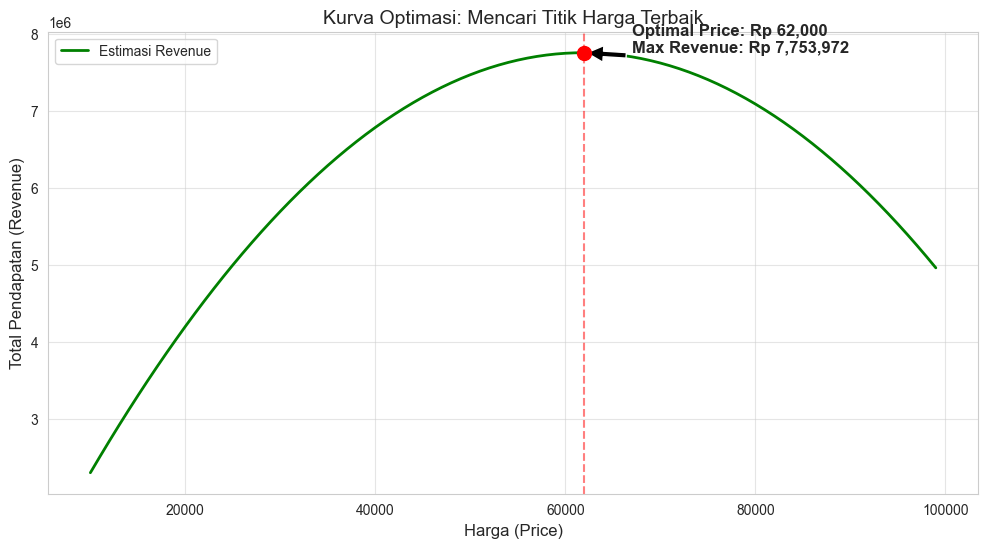

Harga saat ini (Rata-rata): Rp 48,637
Rekomendasi Harga Optimal : Rp 62,000


In [9]:
# 1. Hitung Intercept (Titik potong) dari data rata-rata
# Rumus: y = mx + c  ->  c = y - mx
intercept = mean_qty - (slope * mean_price)

# 2. Buat simulasi rentang harga yang lebih luas (Dari 0 sampai 100.000)
price_range = np.arange(10000, 100000, 1000)

# 3. Prediksi Qty terjual untuk setiap titik harga
predicted_qty = intercept + (slope * price_range)
# Pastikan tidak ada qty negatif
predicted_qty = np.maximum(predicted_qty, 0)

# 4. Hitung Estimasi Revenue (Harga x Qty Prediksi)
estimated_revenue = price_range * predicted_qty

# 5. Cari Titik Revenue Tertinggi (Optimal Price)
max_revenue_index = np.argmax(estimated_revenue)
optimal_price = price_range[max_revenue_index]
max_revenue = estimated_revenue[max_revenue_index]

# 6. Visualisasi Kurva Optimasi
plt.figure(figsize=(12, 6))

# Plot Garis Revenue
plt.plot(price_range, estimated_revenue, color='green', linewidth=2, label='Estimasi Revenue')

# Tandai Titik Puncak
plt.scatter(optimal_price, max_revenue, color='red', s=100, zorder=5)
plt.axvline(x=optimal_price, color='red', linestyle='--', alpha=0.5)

# Anotasi Teks
plt.annotate(f'Optimal Price: Rp {optimal_price:,.0f}\nMax Revenue: Rp {max_revenue:,.0f}',
             xy=(optimal_price, max_revenue), 
             xytext=(optimal_price+5000, max_revenue),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Kurva Optimasi: Mencari Titik Harga Terbaik', fontsize=14)
plt.xlabel('Harga (Price)', fontsize=12)
plt.ylabel('Total Pendapatan (Revenue)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

print(f"Harga saat ini (Rata-rata): Rp {mean_price:,.0f}")
print(f"Rekomendasi Harga Optimal : Rp {optimal_price:,.0f}")